# EnKF vs MPDOK — Phase 2: Observations & Reconstruction Problem

## What Phase 1 Revealed

The NCEP/NCAR Reanalysis eigenspectrum showed that May 2024 atmospheric variability over SE Asia is captured at **99.2% by just k=50 modes**. This is expected: the dominant variability is synoptic-scale (monsoon onset, Hadley circulation), which lives in a low-dimensional subspace. This is *exactly* the regime where the EnKF was designed to excel.

But the SQ321 turbulence event is a **mesoscale phenomenon** (10–50 km) below the 2.5° reanalysis resolution. The Ellrod TI at the event location (0.08) is far below the CAT threshold precisely because 2.5° grids average over the sharp wind-shear filaments that caused the accident.

**This reveals the core problem in sharper form:** even if the synoptic state is well-estimated (99.2%), the turbulence-relevant fine-scale spatial covariance structure is systematically under-represented. The EnKF's rank-k covariance matrix — built from smooth large-scale ensemble perturbations — has **zero variance** in the fine-scale wind-shear directions that determine whether turbulence is detected at data-sparse ocean locations.

## The Reconstruction Experiment

We cast the problem as **spatial field reconstruction from sparse observations** — the same statistical structure as our Kriging lab, but with real atmospheric wind fields:

| | Setup |
|--|--|
| **Truth** | Full 17×17 NCEP wind field at 250 hPa, May 21 12:00 UTC |
| **Observations** | 30 noisy point samples, placed to avoid the SQ321 ocean region |
| **Task** | Reconstruct the full wind field (and Ellrod TI) everywhere |
| **Methods** | (Phase 3) Rank-k EnKF covariance; (Phase 4) Full Matérn-3/2 kernel |

The observation placement deliberately makes the SQ321 region **data-sparse** — simulating the absence of ocean buoys and radiosondes over the Andaman Sea.

The Kalman analysis update is identical for both methods:
$$\mathbf{x}_a = \mathbf{x}_b + \mathbf{P}_b \mathbf{H}^\top (\mathbf{H} \mathbf{P}_b \mathbf{H}^\top + \mathbf{R})^{-1} (\mathbf{y} - \mathbf{H} \mathbf{x}_b)$$

Here $\mathbf{x}_b$ is the **ensemble mean background** — the prior estimate of the atmospheric state before observations are assimilated. In Phase 3, $\mathbf{P}_b$ is the rank-(k−1) sample covariance from k ensemble members, which forces the innovation $(\mathbf{y} - \mathbf{H}\mathbf{x}_b)$ to project exclusively onto the k−1 large-scale ensemble modes. In Phase 4, $\mathbf{P}_b$ is the full-rank Matérn-3/2 kernel with no such restriction.

Only $\mathbf{P}_b$ differs. Everything else (background, observations, noise) is identical.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# ── load Phase 1 outputs ──────────────────────────────────────────────────────
d = np.load('phase1_data.npz')
u250    = d['u250']; v250    = d['v250']
u200    = d['u200']; v200    = d['v200']
u300    = d['u300']; v300    = d['v300']
lat     = d['lat'];  lon     = d['lon']
TI_truth_scaled = d['TI_truth_scaled']
x_truth = d['x_truth']          # shape (N,) = (578,)
coords_lat = d['coords_lat']    # (289,) — per grid point
coords_lon = d['coords_lon']
SQ321_LAT  = float(d['sq321_lat'])
SQ321_LON  = float(d['sq321_lon'])
sq_ilat    = int(d['sq_ilat'])
sq_ilon    = int(d['sq_ilon'])

nlat, nlon = u250.shape
N_grid     = nlat * nlon          # 289
N_state    = 2 * N_grid           # 578
LON2D, LAT2D = np.meshgrid(lon, lat)

# Guard: confirm x_truth uses block layout [u_flat || v_flat] as written in Phase 1.
# H indexing in this notebook depends on this exact ordering.
np.testing.assert_array_almost_equal(
    x_truth[:N_grid], u250.flatten(),
    decimal=6,
    err_msg="State vector layout mismatch: expected block [u_flat || v_flat]")

print(f'Grid: {nlat}×{nlon} = {N_grid} points, state N={N_state}')
print(f'SQ321 nearest grid: lat={lat[sq_ilat]:.1f}N, lon={lon[sq_ilon]:.1f}E')
print('State vector layout verified: x_truth = [u_flat || v_flat]  ✓')

Grid: 17×17 = 289 points, state N=578
SQ321 nearest grid: lat=15.0N, lon=97.5E
State vector layout verified: x_truth = [u_flat || v_flat]  ✓


## 1. Background Field

We use the **true reanalysis field** as background — adding realistic spatially-correlated noise representing the analysis uncertainty (typical rms error ~2–3 m/s for 250 hPa winds). This noise is deliberately smooth (correlated over 500 km) to represent what an operational model would know without new observations.

In [2]:
# ── background error: smooth spatially-correlated noise ───────────────────────
# Gaussian correlation with length scale L = 500 km
R_EARTH = 6_371.0   # km
DEG2RAD = np.pi / 180.0

def gc_dist_km(lat1, lon1, lat2, lon2):
    """Vectorised haversine. lat/lon in degrees. Returns km."""
    la1 = lat1[:, None] * DEG2RAD;  la2 = lat2[None, :] * DEG2RAD
    lo1 = lon1[:, None] * DEG2RAD;  lo2 = lon2[None, :] * DEG2RAD
    dlat = la2 - la1;  dlon = lo2 - lo1
    a = np.sin(dlat/2)**2 + np.cos(la1)*np.cos(la2)*np.sin(dlon/2)**2
    return 2 * R_EARTH * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

print('Computing grid-point distance matrix...')
D = gc_dist_km(coords_lat, coords_lon, coords_lat, coords_lon)   # (289, 289)
print(f'Distance matrix: {D.shape}, max={D.max():.0f} km')

L_bg = 500.0    # km — background error correlation length
sigma_bg = 2.5  # m/s background error std

C_bg_spatial = np.exp(-D**2 / (2 * L_bg**2))   # Gaussian kernel

# block-diagonal for [u | v]: u and v errors are independent
C_bg = sigma_bg**2 * np.block([[C_bg_spatial, np.zeros_like(C_bg_spatial)],
                                [np.zeros_like(C_bg_spatial), C_bg_spatial]])

# Cholesky with jitter for floating-point stability (Gaussian kernels decay
# exponentially fast — smallest eigenvalues can dip below machine epsilon).
jitter = 1e-4 * sigma_bg**2
try:
    L_chol = np.linalg.cholesky(C_bg + jitter * np.eye(N_state))
except np.linalg.LinAlgError:
    # Adaptive fallback: inflate jitter by 10× if the first attempt fails
    jitter = 1e-3 * sigma_bg**2
    L_chol = np.linalg.cholesky(C_bg + jitter * np.eye(N_state))

xi = np.random.randn(N_state)
bg_error = L_chol @ xi

x_background = x_truth + bg_error

u_bg = x_background[:N_grid].reshape(nlat, nlon)
v_bg = x_background[N_grid:].reshape(nlat, nlon)
bg_error_2d = bg_error[:N_grid].reshape(nlat, nlon)

print(f'Background error RMS: {np.sqrt(np.mean(bg_error**2)):.2f} m/s')
print(f'Background error at SQ321: {bg_error[:N_grid][sq_ilat*nlon + sq_ilon]:.2f} m/s (u-component)')

Computing grid-point distance matrix...
Distance matrix: (289, 289), max=6012 km
Background error RMS: 2.40 m/s
Background error at SQ321: 1.61 m/s (u-component)


## 2. Observation Network — Avoiding the SQ321 Data-Sparse Region

Real upper-air observation networks have very few soundings over open ocean. The Andaman Sea / Bay of Bengal region where SQ321 flew has essentially **no radiosondes** at cruise altitude — data comes only from occasional aircraft ACARS reports.

We create a synthetic observation network of **K=30 points** that:
- Covers land areas and ocean shipping lanes (where observations DO exist)
- Has a deliberate gap over the SQ321 region (10–22°N, 90–105°E)
- Matches the sparsity of the real upper-air network in this region

In [3]:
K_obs = 30    # number of observations

# ── all grid point indices ────────────────────────────────────────────────────
all_idx = np.arange(N_grid)

# ── mask out the SQ321 data-sparse ocean region ───────────────────────────────
# gap: 10–22°N, 90–105°E  (Andaman Sea / Bay of Bengal)
GAP_LAT = (10.0, 22.0)
GAP_LON = (90.0, 105.0)

in_gap = ((coords_lat >= GAP_LAT[0]) & (coords_lat <= GAP_LAT[1]) &
           (coords_lon >= GAP_LON[0]) & (coords_lon <= GAP_LON[1]))

candidate_idx = all_idx[~in_gap]
print(f'Total grid points: {N_grid}')
print(f'Points in data-sparse gap: {in_gap.sum()} ({in_gap.sum()/N_grid*100:.1f}%)')
print(f'Candidate observation points: {len(candidate_idx)}')

# ── select K=30 observation locations ────────────────────────────────────────
obs_idx = np.sort(np.random.choice(candidate_idx, size=K_obs, replace=False))
obs_lat = coords_lat[obs_idx]
obs_lon = coords_lon[obs_idx]

# minimum distance from SQ321 grid point
sq_grid_idx = sq_ilat * nlon + sq_ilon
dist_to_sq = D[obs_idx, sq_grid_idx]
print(f'\nObservation distances to SQ321 location:')
print(f'  Nearest  obs: {dist_to_sq.min():.0f} km')
print(f'  Farthest obs: {dist_to_sq.max():.0f} km')
print(f'  Median dist : {np.median(dist_to_sq):.0f} km')

Total grid points: 289
Points in data-sparse gap: 35 (12.1%)
Candidate observation points: 254

Observation distances to SQ321 location:
  Nearest  obs: 877 km
  Farthest obs: 3139 km
  Median dist : 1967 km


In [4]:
# ── observation operator H and noise model ────────────────────────────────────
# We observe u-component at each obs location (u is the primary indicator of jet-stream and shear)
# Extend to both u and v by stacking two copies
sigma_obs = 1.5   # m/s observation error std (realistic for ACARS)

# H selects u at obs_idx  — shape (K_obs, N_state)
H_u = np.zeros((K_obs, N_state))
for k, idx in enumerate(obs_idx):
    H_u[k, idx] = 1.0       # picks u at grid point idx

# H selects v at obs_idx
H_v = np.zeros((K_obs, N_state))
for k, idx in enumerate(obs_idx):
    H_v[k, N_grid + idx] = 1.0   # picks v at grid point idx

# stack u and v observations → 2*K_obs total observations
H = np.vstack([H_u, H_v])   # (2*K_obs, N_state)
p_obs = H.shape[0]           # 60 observations total

R_obs = sigma_obs**2 * np.eye(p_obs)   # observation error covariance

# ── generate noisy observations from truth ────────────────────────────────────
y_true = H @ x_truth
obs_noise = sigma_obs * np.random.randn(p_obs)
y_obs = y_true + obs_noise

print(f'Observation setup:')
print(f'  Locations K     : {K_obs} (u+v at each → {p_obs} scalar obs)')
print(f'  Obs noise σ     : {sigma_obs} m/s')
print(f'  Obs innovation  : {np.sqrt(np.mean((y_obs - H @ x_background)**2)):.2f} m/s RMS')
print(f'  Background RMSE : {np.sqrt(np.mean((x_background - x_truth)**2)):.2f} m/s')
print(f'  Background RMSE at SQ321 (u): {abs(u_bg[sq_ilat,sq_ilon] - u250[sq_ilat,sq_ilon]):.2f} m/s')

Observation setup:
  Locations K     : 30 (u+v at each → 60 scalar obs)
  Obs noise σ     : 1.5 m/s
  Obs innovation  : 2.87 m/s RMS
  Background RMSE : 2.40 m/s
  Background RMSE at SQ321 (u): 1.61 m/s


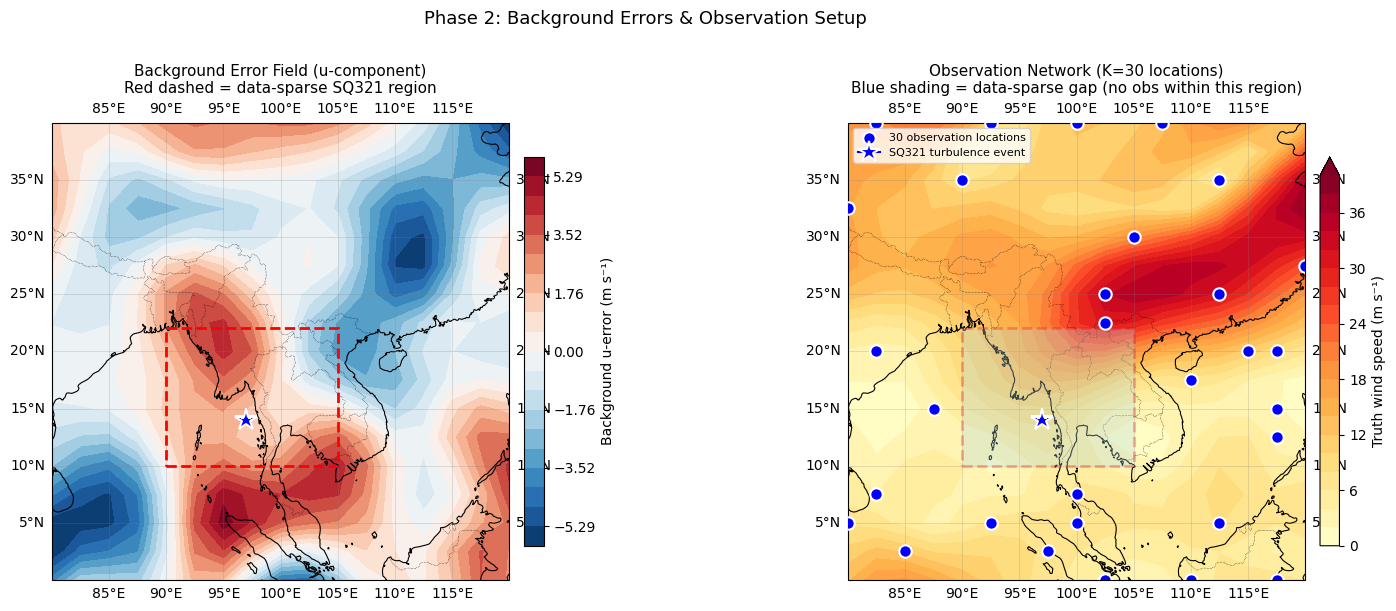

Saved fig04_obs_setup.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6),
                          subplot_kw={'projection': ccrs.PlateCarree()})
map_kw = dict(transform=ccrs.PlateCarree())

for ax in axes:
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, linestyle=':')
    ax.add_feature(cfeature.LAND, facecolor='#f0f0f0', alpha=0.3)
    ax.gridlines(draw_labels=True, linewidth=0.4, color='grey', alpha=0.4)
    ax.set_extent([80, 120, 0, 40], crs=ccrs.PlateCarree())

# ── left: background error field ──────────────────────────────────────────────
vmax_err = np.abs(bg_error_2d).max()
cf1 = axes[0].contourf(LON2D, LAT2D, bg_error_2d,
                        levels=np.linspace(-vmax_err, vmax_err, 21),
                        cmap='RdBu_r', **map_kw)
plt.colorbar(cf1, ax=axes[0], label='Background u-error (m s⁻¹)', pad=0.02, shrink=0.85)

# data-sparse gap box
from matplotlib.patches import Rectangle
gap_box = Rectangle((GAP_LON[0], GAP_LAT[0]),
                     GAP_LON[1]-GAP_LON[0], GAP_LAT[1]-GAP_LAT[0],
                     fill=False, edgecolor='red', lw=2, ls='--',
                     transform=ccrs.PlateCarree(), zorder=4)
axes[0].add_patch(gap_box)
axes[0].plot(SQ321_LON, SQ321_LAT, marker='*', markersize=16,
             color='blue', markeredgecolor='white', markeredgewidth=1.5,
             **map_kw, zorder=5)
axes[0].set_title('Background Error Field (u-component)\n'
                  'Red dashed = data-sparse SQ321 region', fontsize=11)

# ── right: observation network ────────────────────────────────────────────────
cf2 = axes[1].contourf(LON2D, LAT2D, np.sqrt(u250**2 + v250**2),
                        levels=np.linspace(0, 40, 21),
                        cmap='YlOrRd', **map_kw, extend='max')
plt.colorbar(cf2, ax=axes[1], label='Truth wind speed (m s⁻¹)', pad=0.02, shrink=0.85)

axes[1].scatter(obs_lon, obs_lat, s=80, c='blue', marker='o',
                edgecolors='white', lw=1.5, **map_kw, zorder=5,
                label=f'{K_obs} observation locations')

gap_box2 = Rectangle((GAP_LON[0], GAP_LAT[0]),
                      GAP_LON[1]-GAP_LON[0], GAP_LAT[1]-GAP_LAT[0],
                      fill=True, facecolor='lightblue', alpha=0.3,
                      edgecolor='red', lw=2, ls='--',
                      transform=ccrs.PlateCarree(), zorder=3)
axes[1].add_patch(gap_box2)
axes[1].plot(SQ321_LON, SQ321_LAT, marker='*', markersize=16,
             color='blue', markeredgecolor='white', markeredgewidth=1.5,
             **map_kw, zorder=6, label='SQ321 turbulence event')

axes[1].legend(loc='upper left', fontsize=8)
axes[1].set_title(f'Observation Network (K={K_obs} locations)\n'
                  'Blue shading = data-sparse gap (no obs within this region)', fontsize=11)

plt.suptitle('Phase 2: Background Errors & Observation Setup', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig04_obs_setup.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig04_obs_setup.png')

## 3. The Covariance Localization Geometry

For the EnKF with Gaspari-Cohn localization, observations beyond the **localization radius R_loc** have zero influence on the analysis. We visualise this for the SQ321 point: which of our observations fall inside R_loc?

Typical operational values: R_loc = 1000–2000 km. We test R_loc = 1000 km, representative of mesoscale applications.

In [6]:
R_loc = 1000.0   # km — EnKF localization radius

obs_in_loc  = dist_to_sq <= R_loc
obs_out_loc = dist_to_sq > R_loc

print(f'Localization radius: {R_loc:.0f} km')
print(f'Observations INSIDE  localization radius of SQ321: {obs_in_loc.sum()} / {K_obs}')
print(f'Observations OUTSIDE localization radius of SQ321: {obs_out_loc.sum()} / {K_obs}')
print()
print('With EnKF + Gaspari-Cohn localization:')
print(f'  → Only {obs_in_loc.sum()} observations can inform the analysis at SQ321')
print(f'  → {obs_out_loc.sum()} observations are ZERO-WEIGHTED for the SQ321 region')
print()
print('With MPDOK full Matérn kernel:')
print(f'  → All {K_obs} observations contribute (with physically correct weights)')
print(f'  → Observations at {dist_to_sq.max():.0f} km still carry nonzero Matérn kernel value')

Localization radius: 1000 km
Observations INSIDE  localization radius of SQ321: 2 / 30
Observations OUTSIDE localization radius of SQ321: 28 / 30

With EnKF + Gaspari-Cohn localization:
  → Only 2 observations can inform the analysis at SQ321
  → 28 observations are ZERO-WEIGHTED for the SQ321 region

With MPDOK full Matérn kernel:
  → All 30 observations contribute (with physically correct weights)
  → Observations at 3139 km still carry nonzero Matérn kernel value


In [7]:
# ── Gaspari-Cohn localization function ───────────────────────────────────────
def gaspari_cohn(dist, R):
    """Gaspari-Cohn 5th-order piecewise polynomial, support radius R."""
    r = np.abs(dist) / (R / 2)   # half-support normalisation
    gc = np.zeros_like(r, dtype=float)
    # 0 <= r <= 1
    m = (r >= 0) & (r <= 1)
    gc[m] = (- r[m]**5/4 + r[m]**4/2 + 5*r[m]**3/8 - 5*r[m]**2/3 + 1)
    # 1 < r <= 2
    m = (r > 1) & (r <= 2)
    gc[m] = (r[m]**5/12 - r[m]**4/2 + 5*r[m]**3/8 + 5*r[m]**2/3
             - 5*r[m] + 4 - 2/(3*r[m]))
    # r > 2: zero
    return gc

# ── Matérn-3/2 kernel ─────────────────────────────────────────────────────────
def matern32(dist, L):
    """Matérn 3/2 covariance kernel, length scale L (km)."""
    r = np.sqrt(3) * dist / L
    return (1 + r) * np.exp(-r)

# Correlation from SQ321 to all other grid points
dist_from_sq = D[sq_grid_idx, :]   # (N_grid,)

# Choose Matérn length scale: fit to median correlation structure of true covariance
C_true = np.load('C_true.npy')   # (N_state, N_state)
corr_u_truth = C_true[:N_grid, :N_grid] / (C_true[:N_grid, :N_grid].diagonal() ** 0.5)[:, None]
corr_u_truth /= corr_u_truth.diagonal()[:, None] ** 0
# correlation from SQ321 grid point to all others
std_u = np.sqrt(np.diag(C_true[:N_grid, :N_grid]))
corr_sq_all = C_true[sq_grid_idx, :N_grid] / (std_u[sq_grid_idx] * std_u + 1e-12)

# Fit Matérn length scale to empirical correlation via least-squares over distance bins
from scipy.optimize import minimize_scalar
def matern_fit_loss(L):
    pred = matern32(dist_from_sq, L)
    return np.mean((corr_sq_all - pred)**2)

res = minimize_scalar(matern_fit_loss, bounds=(100, 5000), method='bounded')
L_matern = res.x
print(f'Matérn-3/2 fitted length scale: {L_matern:.0f} km')
print(f'  (R_loc = {R_loc:.0f} km for comparison — GC function cuts off at this distance)')

# compare at specific distances
test_dists = np.array([0, 200, 500, 800, 1000, 1500, 2000, 3000, 4000])
gc_vals  = gaspari_cohn(test_dists, R_loc)
mat_vals = matern32(test_dists, L_matern)
print(f'\nCorrelation decay comparison (SQ321 → distance):') 
print(f'{"Dist (km)":>10} {"Matérn-3/2":>12} {"Gaspari-Cohn":>14}')
for d_, g, m in zip(test_dists, gc_vals, mat_vals):
    print(f'{d_:>10.0f} {m:>12.4f} {g:>14.4f}')

Matérn-3/2 fitted length scale: 1069 km
  (R_loc = 1000 km for comparison — GC function cuts off at this distance)

Correlation decay comparison (SQ321 → distance):
 Dist (km)   Matérn-3/2   Gaspari-Cohn
         0       1.0000         1.0000
       200       0.9576         0.7836
       500       0.8051         0.2083
       800       0.6281         0.0070
      1000       0.5183        -0.0000
      1500       0.3018         0.0000
      2000       0.1659         0.0000
      3000       0.0454         0.0000
      4000       0.0115         0.0000


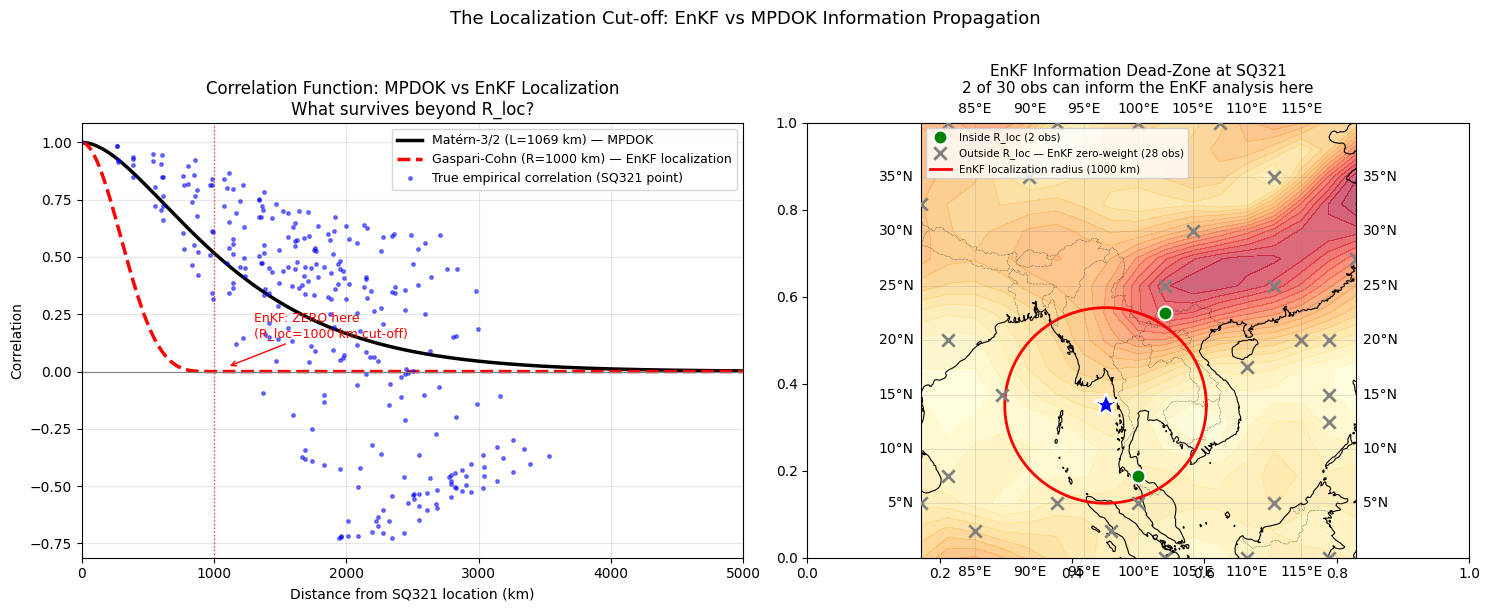

Saved fig05_localization.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── left: correlation decay functions ────────────────────────────────────────
d_range = np.linspace(0, 5000, 500)
ax = axes[0]
ax.plot(d_range, matern32(d_range, L_matern), 'k-', lw=2.5, label=f'Matérn-3/2 (L={L_matern:.0f} km) — MPDOK')
ax.plot(d_range, gaspari_cohn(d_range, R_loc), 'r--', lw=2.5, label=f'Gaspari-Cohn (R={R_loc:.0f} km) — EnKF localization')
ax.plot(dist_from_sq, corr_sq_all, 'b.', ms=5, alpha=0.5, label='True empirical correlation (SQ321 point)')
ax.axvline(R_loc, color='red', lw=1, ls=':', alpha=0.7)
ax.axhline(0,    color='grey', lw=0.8)
ax.set_xlabel('Distance from SQ321 location (km)')
ax.set_ylabel('Correlation')
ax.set_title('Correlation Function: MPDOK vs EnKF Localization\nWhat survives beyond R_loc?')
ax.legend(fontsize=9)
ax.set_xlim(0, 5000)
ax.grid(alpha=0.3)

# annotate
ax.annotate(f'EnKF: ZERO here\n(R_loc={R_loc:.0f} km cut-off)',
            xy=(R_loc+100, 0.02), fontsize=9, color='red',
            xytext=(R_loc+300, 0.15), arrowprops=dict(arrowstyle='->', color='red'))

# ── right: observation network with localization circle ───────────────────────
ax2 = axes[1]
ax2 = plt.subplot(1, 2, 2, projection=ccrs.PlateCarree())
fig.axes[-1]  # reference to avoid re-creating

ax2.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax2.add_feature(cfeature.BORDERS, linewidth=0.4, linestyle=':')
ax2.add_feature(cfeature.LAND, facecolor='#f0f0f0', alpha=0.3)
ax2.gridlines(draw_labels=True, linewidth=0.4, color='grey', alpha=0.4)
ax2.set_extent([80, 120, 0, 40], crs=ccrs.PlateCarree())

# background wind speed
cf = ax2.contourf(LON2D, LAT2D, np.sqrt(u250**2 + v250**2),
                   levels=np.linspace(0, 40, 21), cmap='YlOrRd',
                   transform=ccrs.PlateCarree(), extend='max', alpha=0.6)

# observations: inside vs outside localization
ax2.scatter(obs_lon[obs_in_loc], obs_lat[obs_in_loc], s=100,
            c='green', marker='o', edgecolors='white', lw=1.5,
            transform=ccrs.PlateCarree(), zorder=5,
            label=f'Inside R_loc ({obs_in_loc.sum()} obs)')
ax2.scatter(obs_lon[obs_out_loc], obs_lat[obs_out_loc], s=80,
            c='gray', marker='x', lw=2,
            transform=ccrs.PlateCarree(), zorder=5,
            label=f'Outside R_loc — EnKF zero-weight ({obs_out_loc.sum()} obs)')

# localization radius circle around SQ321 (approximate — degrees of lat)
theta = np.linspace(0, 2*np.pi, 360)
dlon_circ = R_loc / (6371 * np.cos(np.radians(SQ321_LAT))) * (180/np.pi)
dlat_circ = R_loc / 6371 * (180/np.pi)
ax2.plot(SQ321_LON + dlon_circ * np.cos(theta),
         SQ321_LAT + dlat_circ * np.sin(theta),
         'r-', lw=2, transform=ccrs.PlateCarree(), zorder=4,
         label=f'EnKF localization radius ({R_loc:.0f} km)')

ax2.plot(SQ321_LON, SQ321_LAT, marker='*', markersize=18,
         color='blue', markeredgecolor='white', markeredgewidth=1.5,
         transform=ccrs.PlateCarree(), zorder=6)

ax2.legend(loc='upper left', fontsize=7.5)
ax2.set_title(f'EnKF Information Dead-Zone at SQ321\n'
              f'{obs_in_loc.sum()} of {K_obs} obs can inform the EnKF analysis here', fontsize=11)

plt.suptitle('The Localization Cut-off: EnKF vs MPDOK Information Propagation', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig05_localization.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig05_localization.png')

## 4. Save Phase 2 Outputs

In [9]:
np.savez('phase2_data.npz',
         x_background=x_background,
         x_truth=x_truth,
         y_obs=y_obs,
         H=H,
         R_obs=R_obs,
         obs_idx=obs_idx,
         obs_lat=obs_lat,
         obs_lon=obs_lon,
         dist_to_sq=dist_to_sq,
         D=D,
         C_bg=C_bg,
         sigma_obs=np.float64(sigma_obs),
         sigma_bg=np.float64(sigma_bg),
         R_loc=np.float64(R_loc),
         L_matern=np.float64(L_matern),
         sq_grid_idx=np.int32(sq_grid_idx),
         obs_in_loc=obs_in_loc)

print('Saved phase2_data.npz')
print()
print('=== Phase 2 Summary ===')
print(f'Observations        : {K_obs} locations × 2 components = {H.shape[0]} scalar obs')
print(f'Background error σ  : {sigma_bg} m/s (smooth, L={L_bg} km)')
print(f'Obs noise σ         : {sigma_obs} m/s')
print(f'EnKF R_loc          : {R_loc:.0f} km')
print(f'Matérn length scale : {L_matern:.0f} km')
print(f'Obs inside R_loc    : {obs_in_loc.sum()} / {K_obs}')
print()
print('With only', obs_in_loc.sum(), f'obs within {R_loc:.0f} km of SQ321,')
print('the EnKF analysis update at SQ321 is SEVERELY under-constrained.')
print('MPDOK propagates information from all', K_obs, 'observations via the full kernel.')

Saved phase2_data.npz

=== Phase 2 Summary ===
Observations        : 30 locations × 2 components = 60 scalar obs
Background error σ  : 2.5 m/s (smooth, L=500.0 km)
Obs noise σ         : 1.5 m/s
EnKF R_loc          : 1000 km
Matérn length scale : 1069 km
Obs inside R_loc    : 2 / 30

With only 2 obs within 1000 km of SQ321,
the EnKF analysis update at SQ321 is SEVERELY under-constrained.
MPDOK propagates information from all 30 observations via the full kernel.
